# 4. Engagement Index

This section develops a standardized Engagement Index using employee involvement, job satisfaction, environment satisfaction, and relationship satisfaction.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load processed dataset

df = pd.read_csv("../data/processed/employee_engagement_dataset.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 31


In [4]:
# Define engagement variables

engagement_columns = [
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction"
]

print("Engagement Variables:")
print(engagement_columns)

Engagement Variables:
['JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']


In [5]:
# Validate engagement variable ranges

for column in engagement_columns:
    print(f"{column}: {sorted(df[column].unique())}")

JobInvolvement: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
JobSatisfaction: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
EnvironmentSatisfaction: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
RelationshipSatisfaction: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [6]:
# Calculate Engagement Index

df["Engagement_Index"] = (
    df["JobInvolvement"]
    + df["JobSatisfaction"]
    + df["EnvironmentSatisfaction"]
    + df["RelationshipSatisfaction"]
) / 4

In [7]:
# Display Engagement Index

df[engagement_columns + ["Engagement_Index"]].head()

,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,Engagement_Index
0,3,4,2,1,2.50
1,2,2,3,4,2.75
2,2,3,4,2,2.75
3,3,3,4,3,3.25
4,3,2,1,4,2.50


In [8]:
# Generate Engagement Index statistics

df["Engagement_Index"].describe()

count    1470.000000
mean        2.723129
std         0.504026
min         1.250000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: Engagement_Index, dtype: float64

In [9]:
# Create Engagement Categories

def engagement_category(score):
    if score < 2:
        return "Low"
    elif score < 3:
        return "Moderate"
    else:
        return "High"

df["Engagement_Category"] = df["Engagement_Index"].apply(
    engagement_category
)

In [10]:
# Check Engagement Categories

df["Engagement_Category"].value_counts()

Engagement_Category
Moderate    814
High        587
Low          69
Name: count, dtype: int64

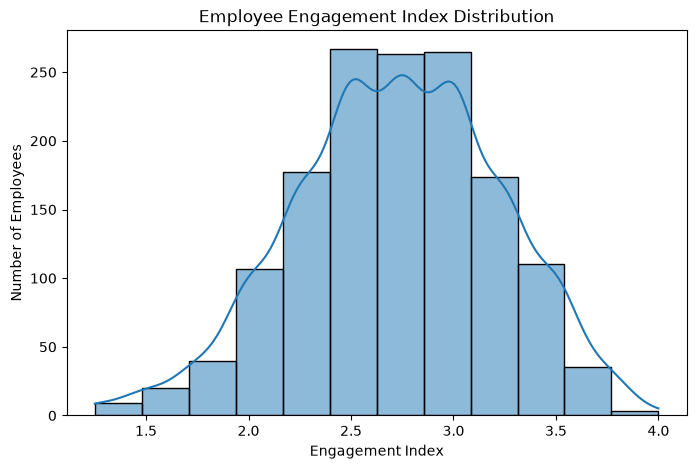

In [11]:
# Plot Engagement Index distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Engagement_Index"],
    bins=12,
    kde=True
)

plt.title("Employee Engagement Index Distribution")
plt.xlabel("Engagement Index")
plt.ylabel("Number of Employees")
plt.show()

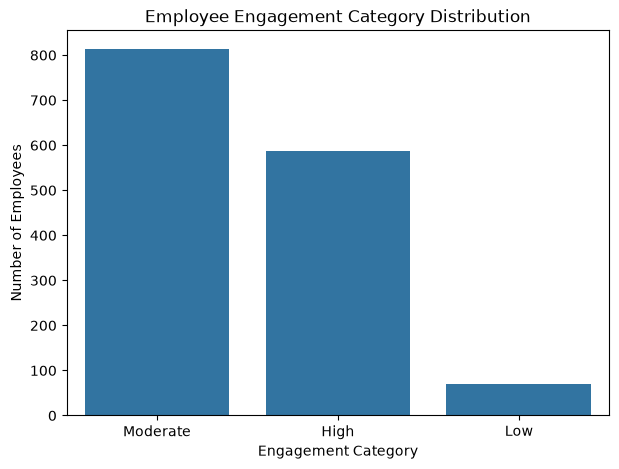

In [12]:
# Plot Engagement Category distribution

category_counts = df["Engagement_Category"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Employee Engagement Category Distribution")
plt.xlabel("Engagement Category")
plt.ylabel("Number of Employees")
plt.show()

In [13]:
# Calculate average Engagement Index by department

department_engagement = (
    df.groupby("Department")["Engagement_Index"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

department_engagement


Department
Research & Development    2.73
Human Resources           2.73
Sales                     2.71
Name: Engagement_Index, dtype: float64

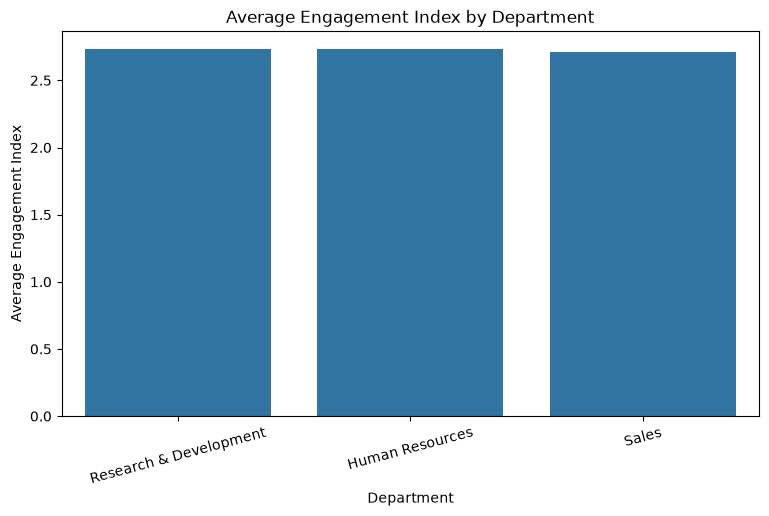

In [14]:
# Plot Engagement Index by department

plt.figure(figsize=(9, 5))

sns.barplot(
    x=department_engagement.index,
    y=department_engagement.values
)

plt.title("Average Engagement Index by Department")
plt.xlabel("Department")
plt.ylabel("Average Engagement Index")
plt.xticks(rotation=15)
plt.show()

In [15]:
# Calculate average Engagement Index by job role

role_engagement = (
    df.groupby("JobRole")["Engagement_Index"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

role_engagement

JobRole
Manager                      2.76
Manufacturing Director       2.75
Research Scientist           2.75
Healthcare Representative    2.75
Sales Executive              2.71
Human Resources              2.71
Laboratory Technician        2.70
Sales Representative         2.68
Research Director            2.67
Name: Engagement_Index, dtype: float64

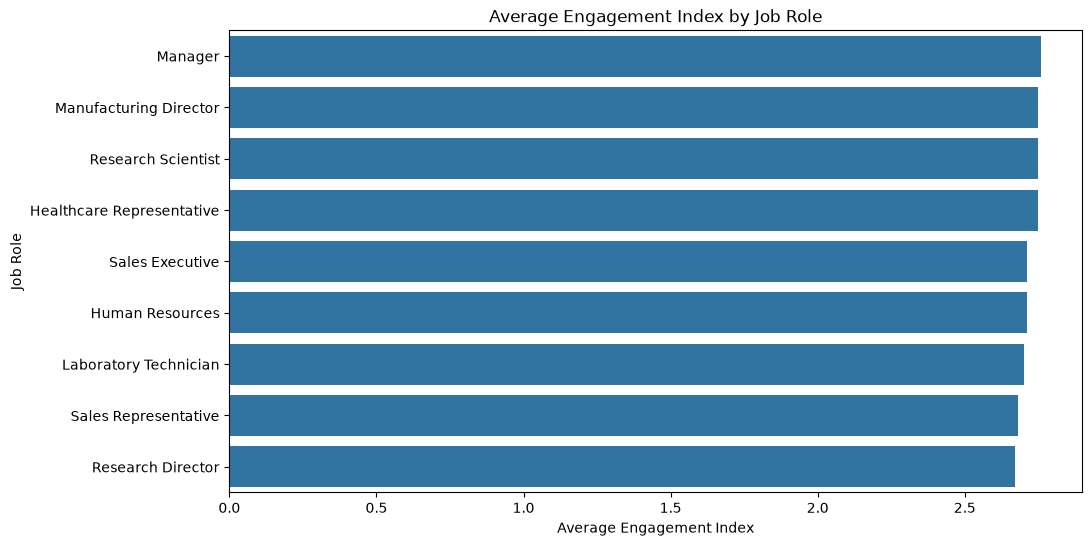

In [16]:
# Plot Engagement Index by job role

plt.figure(figsize=(11, 6))

sns.barplot(
    x=role_engagement.values,
    y=role_engagement.index
)

plt.title("Average Engagement Index by Job Role")
plt.xlabel("Average Engagement Index")
plt.ylabel("Job Role")
plt.show()

In [17]:
# Calculate average Engagement Index by job level

joblevel_engagement = (
    df.groupby("JobLevel")["Engagement_Index"]
    .mean()
    .round(2)
)

joblevel_engagement

JobLevel
1    2.73
2    2.73
3    2.67
4    2.78
5    2.75
Name: Engagement_Index, dtype: float64

In [18]:
# Compare Engagement Index by attrition status

attrition_engagement = (
    df.groupby("Attrition")["Engagement_Index"]
    .mean()
    .round(2)
)

attrition_engagement

Attrition
0    2.76
1    2.51
Name: Engagement_Index, dtype: float64

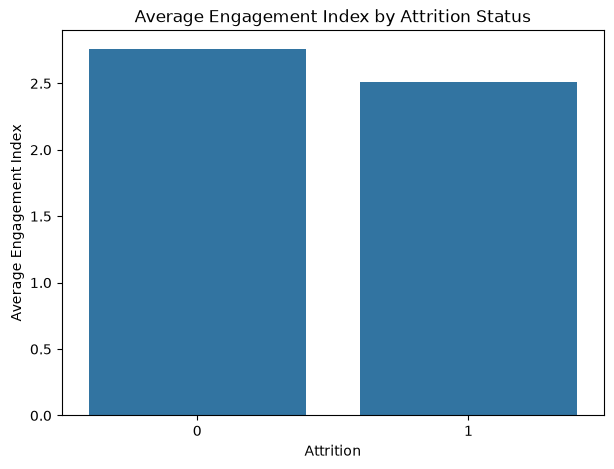

In [19]:
# Plot Engagement Index by attrition status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=attrition_engagement.index,
    y=attrition_engagement.values
)

plt.title("Average Engagement Index by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Engagement Index")
plt.show()

In [20]:
# Identify low-engagement employees

low_engagement = df[
    df["Engagement_Category"] == "Low"
]

print("Low Engagement Employees:", len(low_engagement))

Low Engagement Employees: 69


In [21]:
# Analyze low-engagement employees by department

low_engagement_department = (
    low_engagement["Department"]
    .value_counts()
)

low_engagement_department

Department
Research & Development    42
Sales                     24
Human Resources            3
Name: count, dtype: int64

In [22]:
# Save dataset with Engagement Index

output_path = "../data/processed/employee_engagement_dataset.csv"

df.to_csv(output_path, index=False)

print("Dataset updated successfully.")
print("File:", output_path)

Dataset updated successfully.
File: ../data/processed/employee_engagement_dataset.csv


## Observation

The Engagement Index was successfully created using Job Involvement, Job Satisfaction, Environment Satisfaction, and Relationship Satisfaction.

The index provides a unified measure of employee engagement on a 1–4 scale. Engagement levels were further categorized into Low, Moderate, and High groups to support employee-level and segment-level diagnostics.

Department, job role, job level, and attrition comparisons provide the foundation for identifying areas with lower employee engagement.